In [1]:
import os
import sys
import pandas as pd

# Add the parent directory to the Python path
sys.path.append(os.path.abspath(os.path.join('..')))

# Now you can import it directly without the dot
from helper import set_seed

set_seed(42)
df = pd.read_csv('/home/theo/Desktop/XAI_Energy_Consumption_Prediction/Data/merged_nord_with_power.csv')

🔑 All random seeds set to: 42


In [2]:
df = df.drop(columns=['Horodatage_Fin', 'Horodatage_Début'])
df.head()

,Date and Time,TMP indoor espacesalaries_s41,HUM indoor espacesalaries_s41,CO2 indoor espacesalaries_s41,VOCT indoor espacesalaries_s41,DBAA indoor espacesalaries_s41,DBAP indoor espacesalaries_s41,LIGHT_LUX indoor espacesalaries_s41,OCCUPANCY_RATE indoor espacesalaries_s41,TMP indoor b20,...,TMP indoor t12,HUM indoor t12,CO2 indoor t12,VOCT indoor t12,DBAA indoor t12,DBAP indoor t12,LIGHT_LUX indoor t12,OCCUPANCY_RATE indoor t12,Valeur,Consommation
0,2026-03-01 00:00:00,17.2,55.0,461.0,16.0,36.0,39.0,0.0,0.0,17.2,...,18.3,49.0,521.0,16.0,37.0,45.0,0.0,0.0,39.0,3.250000
1,2026-03-01 00:10:00,17.2,54.0,452.0,20.0,36.0,39.0,0.0,0.0,17.2,...,18.2,49.0,529.0,20.0,36.0,40.0,0.0,0.0,38.0,3.166667
2,2026-03-01 00:20:00,17.2,54.0,442.0,32.0,37.0,40.0,0.0,0.0,17.2,...,18.3,49.0,518.0,21.0,38.0,49.0,0.0,0.0,27.0,2.250000
3,2026-03-01 00:30:00,17.2,54.0,446.0,28.0,37.0,46.0,0.0,0.0,17.2,...,18.2,49.0,519.0,19.0,37.0,44.0,0.0,0.0,16.0,1.333333
4,2026-03-01 00:40:00,17.1,54.0,453.0,20.0,36.0,42.0,0.0,0.0,NaN,...,18.2,49.0,507.0,29.0,37.0,45.0,0.0,0.0,23.0,1.916667


In [3]:
df.isnull().sum()

Date and Time                       0
TMP indoor espacesalaries_s41     123
HUM indoor espacesalaries_s41     123
CO2 indoor espacesalaries_s41     123
VOCT indoor espacesalaries_s41    123
                                 ... 
DBAP indoor t12                   251
LIGHT_LUX indoor t12              251
OCCUPANCY_RATE indoor t12         251
Valeur                              0
Consommation                        0
Length: 223, dtype: int64

## 1. Setup PyTorch Environment
Import essential PyTorch libraries and ensure CUDA access if available.

In [4]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

print("PyTorch Version:", torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

PyTorch Version: 2.5.1+cu124
Using device: cuda


## 2. Prepare Data
Handle missing values, isolate the `Consommation` target variable, and scale the features symmetrically using `StandardScaler`.

In [5]:
# Drop datetime strings (not numeric) and 'Valeur' (excluded: it leaks
# information about the target, e.g. it's another representation of
# Consommation, so keeping it as an input feature would let the model
# 'cheat' instead of learning from the real predictive signals).
cols_to_drop = ['Date and Time', 'Horodatage_Début', 'Horodatage_Fin', 'Valeur']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

df_numeric = df.drop(columns=cols_to_drop)

# Forward fill then backward fill nicely handles sequence missing data gaps!
df_numeric = df_numeric.ffill().bfill()

# Target column: Consommation is what we want to predict.
target_col_name = 'Consommation'
assert target_col_name in df_numeric.columns, f"'{target_col_name}' not found in dataframe columns!"
target_idx = df_numeric.columns.get_loc(target_col_name)

# Standardize to 0 mean and 1 variance
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_numeric.values)
print(f"Transformed sequence shape: {data_scaled.shape}")

Transformed sequence shape: (9648, 221)


## 3. Dataset and DataLoader
Windowing the time-series arrays and batching them for optimal LSTM sequence prediction! By leveraging `Subsets`, we avoid sequential leakage over our chronological timeline that typical `random_split` brings.

In [6]:
class PowerConsumptionDataset(Dataset):
    def __init__(self, data, target_col_idx, seq_length=12):
        self.data = data
        self.target_col_idx = target_col_idx
        self.seq_length = seq_length
        
    def __len__(self):
        return len(self.data) - self.seq_length
        
    def __getitem__(self, idx):
        # Input history (e.g. past 2 hours block)
        x = self.data[idx : idx + self.seq_length, :]
        # Output target prediction (next value in line!)
        y = self.data[idx + self.seq_length, self.target_col_idx]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

seq_length = 12 
dataset = PowerConsumptionDataset(data_scaled, target_col_idx=target_idx, seq_length=seq_length)

# 80/20 chronological validation splitting
train_size = int(0.8 * len(dataset))
train_dataset = torch.utils.data.Subset(dataset, range(0, train_size))
val_dataset = torch.utils.data.Subset(dataset, range(train_size, len(dataset)))

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 121 | Val batches: 31


## 4. LSTM Architecture
A powerful recurrent architecture to learn memory from historical sensor/power dynamics, resolving common gradient loss patterns!

In [7]:
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size=1):
        super(RNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.rnn(x, (h0, c0))
        # Keep solely the outcome generated globally post sequence inference
        out = self.fc(out[:, -1, :])
        return out

input_size = data_scaled.shape[1]
hidden_size = 64
num_layers = 2

model = RNNModel(input_size, hidden_size, num_layers).to(device)
print(model)

RNNModel(
  (rnn): LSTM(221, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


## 5. Iteration Engine
Initialize parameters, process sequential matrices efficiently across our computation `device`, capture backward gradients to mathematically hone errors!

In [8]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20

train_losses = []
val_losses = []

print(f"Starting neural convergence loop on {device}...")

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs.squeeze(), y_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * X_batch.size(0)
        
    train_loss /= len(train_dataset)
    train_losses.append(train_loss)
    
    # Eval Step
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs.squeeze(), y_batch)
            val_loss += loss.item() * X_batch.size(0)
            
    val_loss /= len(val_dataset)
    val_losses.append(val_loss)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1:02d}/{num_epochs}], Train MSE: {train_loss:.4f}, Val MSE: {val_loss:.4f}')

print("Training fully concluded!")

Starting neural convergence loop on cuda...
Epoch [01/20], Train MSE: 0.2531, Val MSE: 0.1319
Epoch [05/20], Train MSE: 0.1051, Val MSE: 0.1049
Epoch [10/20], Train MSE: 0.0835, Val MSE: 0.1123
Epoch [15/20], Train MSE: 0.0669, Val MSE: 0.1241
Epoch [20/20], Train MSE: 0.0531, Val MSE: 0.1127
Training fully concluded!


## 6. Metric Tracking Graphs
Let's review how closely the model adjusted to our training sequence!

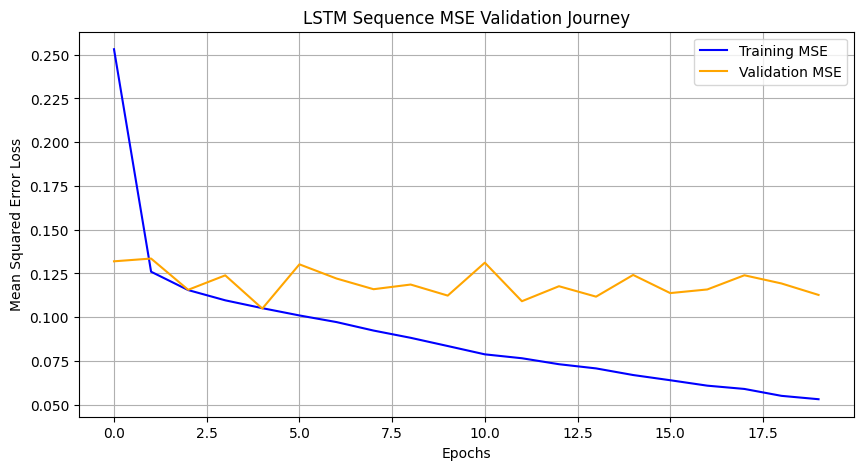

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training MSE', color='blue')
plt.plot(val_losses, label='Validation MSE', color='orange')
plt.title('LSTM Sequence MSE Validation Journey')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error Loss')
plt.legend()
plt.grid(True)
plt.show()

## 7. Model Predictions on Test Set
Predict only on the test set (validation split) and visualize the model's accuracy on unseen future sequential data!

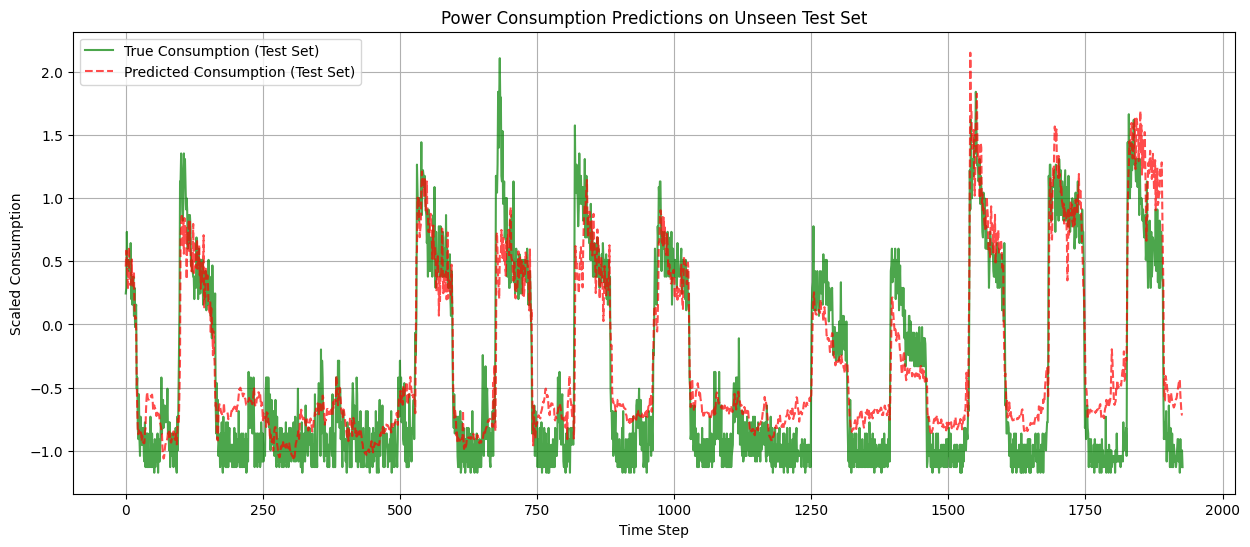

In [10]:
model.eval()
test_predictions = []
test_actuals = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        test_predictions.extend(outputs.squeeze().cpu().numpy())
        test_actuals.extend(y_batch.numpy())

plt.figure(figsize=(15, 6))
plt.plot(test_actuals, label='True Consumption (Test Set)', alpha=0.7, color='green')
plt.plot(test_predictions, label='Predicted Consumption (Test Set)', alpha=0.7, color='red', linestyle='--')
plt.title('Power Consumption Predictions on Unseen Test Set')
plt.xlabel('Time Step')
plt.ylabel('Scaled Consumption')
plt.legend()
plt.grid(True)
plt.show()

## 8. Test Set Evaluation Metrics
Quantify how well the LSTM generalizes to unseen data using **MAE**, **MSE**, **NRMSE**, and **R²**, computed in the original (physical) units of `Consommation` by inverting the `StandardScaler` transform.


In [11]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

test_predictions = np.array(test_predictions)
test_actuals = np.array(test_actuals)

def inverse_transform_target(values_scaled, scaler, col_idx):
    """Invert StandardScaler scaling for a single column (the target)."""
    mean = scaler.mean_[col_idx]
    scale = scaler.scale_[col_idx]
    return values_scaled * scale + mean

# Convert predictions/actuals back to original (physical) units so the
# metrics below are interpretable in real consumption units, not z-scores.
test_predictions_orig = inverse_transform_target(test_predictions, scaler, target_idx)
test_actuals_orig = inverse_transform_target(test_actuals, scaler, target_idx)

mae = mean_absolute_error(test_actuals_orig, test_predictions_orig)
mse = mean_squared_error(test_actuals_orig, test_predictions_orig)
rmse = np.sqrt(mse)

# NRMSE = RMSE normalized by the range (max - min) of the true values.
# This expresses the error as a fraction of the total spread of the target,
# making it comparable across datasets/units.
value_range = test_actuals_orig.max() - test_actuals_orig.min()
nrmse = rmse / value_range if value_range != 0 else float('nan')

r2 = r2_score(test_actuals_orig, test_predictions_orig)

print("Test Set Performance (original units)")
print("-" * 40)
print(f"MAE   : {mae:.4f}")
print(f"MSE   : {mse:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"NRMSE : {nrmse:.4f}  (RMSE / (max - min) of true values)")
print(f"R2    : {r2:.4f}")


Test Set Performance (original units)
----------------------------------------
MAE   : 0.5126
MSE   : 0.3987
RMSE  : 0.6315
NRMSE : 0.1024  (RMSE / (max - min) of true values)
R2    : 0.8134


## 9. SHAP Feature Importance
Use `shap.GradientExplainer` (works directly with PyTorch models, including recurrent layers) to estimate how much each input feature contributes to the LSTM's predictions on the test set. Since each sample is a sequence of `seq_length` past timesteps, we collapse the time dimension by summing absolute SHAP values across timesteps, giving one importance score per feature per sequence.


In [12]:
import shap
import copy

feature_names = df_numeric.columns.tolist()

# GradientExplainer needs a "background" set of sequences (reference distribution)
# and the sequences we actually want explanations for.
n_background = 100   # size of the background/reference sample (larger = more stable, slower)
n_explain = 200       # number of test sequences to explain (larger = more robust, slower)

rng = np.random.default_rng(42)
background_idx = rng.choice(len(train_dataset), size=min(n_background, len(train_dataset)), replace=False)
background = torch.stack([train_dataset[i][0] for i in background_idx])

explain_idx = np.arange(min(n_explain, len(val_dataset)))
test_seqs = torch.stack([val_dataset[i][0] for i in explain_idx])

# IMPORTANT: run SHAP on a CPU copy of the model, even if training used a GPU.
# cuDNN's LSTM implementation refuses to run backward() while the module is
# in eval() mode ("cudnn RNN backward can only be called in training mode"),
# and GradientExplainer needs exactly that. The plain (non-cuDNN) LSTM kernel
# used on CPU has no such restriction, and is plenty fast for this sample size.
model_cpu = copy.deepcopy(model).to("cpu").eval()
background = background.to("cpu")
test_seqs = test_seqs.to("cpu")

explainer = shap.GradientExplainer(model_cpu, background)
shap_values = explainer.shap_values(test_seqs)

# shap_values shape is (n_explain, seq_length, n_features, 1) for a single-output model -> drop last dim
sv = np.array(shap_values)
if sv.ndim == 4:
    sv = sv[..., 0]

# Collapse the time dimension: sum |SHAP| across the seq_length timesteps so
# each feature gets ONE importance value per sequence (easier to interpret
# than a per-timestep breakdown).
shap_per_feature_abs = np.abs(sv).sum(axis=1)   # shape: (n_explain, n_features)
shap_per_feature_signed = sv.sum(axis=1)        # signed version, keeps direction of effect

# ---- Ranked global importance table ----
mean_abs_shap = shap_per_feature_abs.mean(axis=0)
importance_df = (
    pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs_shap})
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
print(importance_df.to_string(index=False))


/home/theo/miniconda3/envs/cesi_duth/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


                                  feature  mean_abs_shap
                             Consommation       0.087408
            TMP indoor espacesalaries_s40       0.066289
                    HUM indoor vaqao_c22a       0.058053
                          VOCT indoor t09       0.057424
                     LIGHT_LUX indoor S35       0.051993
                    HUM indoor vaqao_c1bb       0.050370
                           HUM indoor b24       0.049068
                           TMP indoor t15       0.047769
                           TMP indoor b15       0.047223
                          VOCT indoor b13       0.045238
                           TMP indoor t18       0.044524
            HUM indoor espacesalaries_s41       0.043294
                          VOCT indoor S35       0.043267
           VOCT indoor espacesalaries_s41       0.040443
                    TMP indoor t24_fablab       0.037837
            HUM indoor espacesalaries_s40       0.036471
                          DBAP 

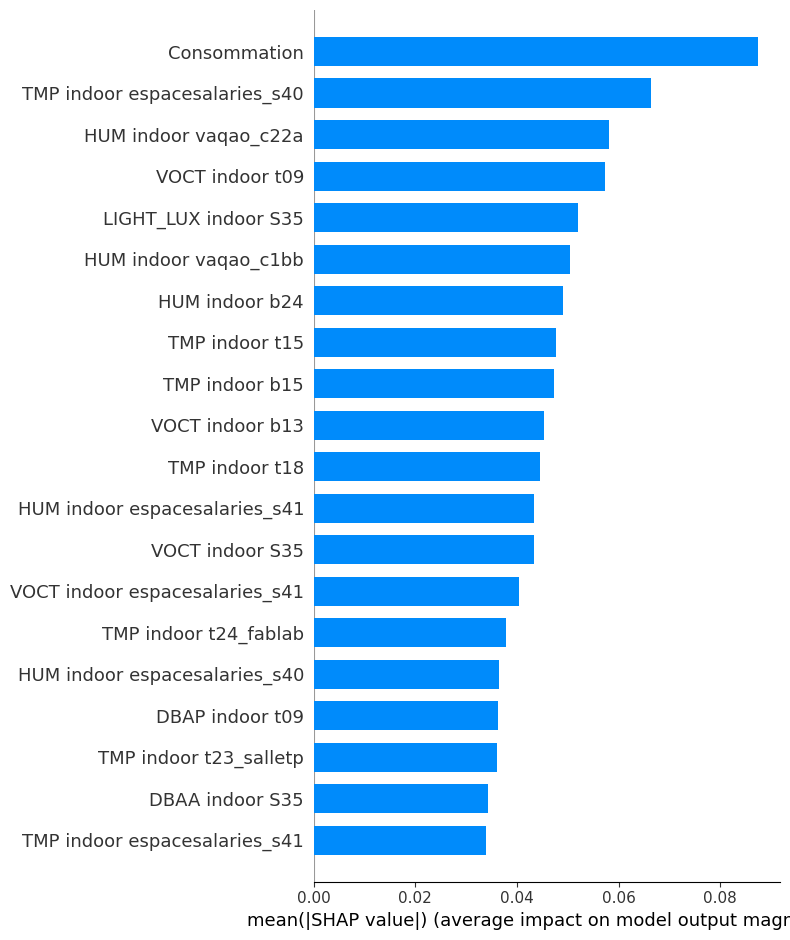

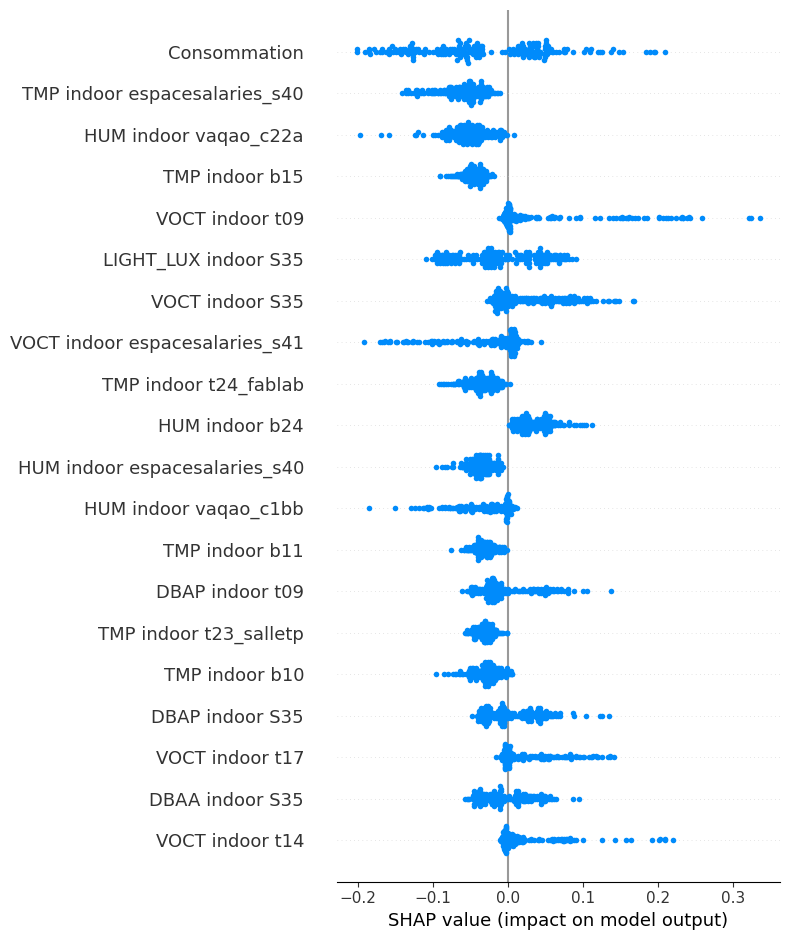

In [13]:
# ---- Global importance bar chart ----
shap.summary_plot(shap_per_feature_abs, feature_names=feature_names, plot_type="bar", show=True)

# ---- Beeswarm plot: shows spread/direction of each feature's effect across test sequences ----
shap.summary_plot(shap_per_feature_signed, feature_names=feature_names, show=True)
